# 6.0: Critical Evaluation, the Business Case, and Where to Be Skeptical

**Question this notebook answers:** what is the actual financial case for shipping this
model, and, just as important, where should a risk-literate reader be skeptical of it?

Everything below is computed from the already-serialized final model scored on the
already-produced test/transfer parquets (inference only), or quoted directly from
`docs/FACTS.md` where the original computation (a 1,000-resample bootstrap, a SHAP
explainer run) is too expensive to redo in a notebook meant to run in seconds. Each
quoted number says so explicitly.

In [1]:
import sys, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score

sys.path.insert(0, str(Path('..').resolve()))
from src.data import load_split, FEATURE_SET, CATEGORICAL_COLS
from src.features import build_features, prepare_X
from src.economics import compute_interest_loss, profit_at_threshold

train = load_split('train')
test = load_split('test')
transfer_60m = load_split('transfer_60m')

X_train = prepare_X(build_features(train), FEATURE_SET, CATEGORICAL_COLS)
test_feat = build_features(test)
X_test = prepare_X(test_feat, FEATURE_SET, CATEGORICAL_COLS).reindex(columns=X_train.columns, fill_value=0)
y_test = test_feat['target'].values
interest_test, loss_test = compute_interest_loss(test_feat)
interest_test, loss_test = interest_test.values, loss_test.values

xgb_final = joblib.load(Path('..') / 'models' / 'xgb_final.joblib')
m1_final = joblib.load(Path('..') / 'models' / 'logistic_baseline.joblib')
y_prob_xgb = xgb_final.predict_proba(X_test)[:, 1]
y_prob_m1 = m1_final.predict_proba(X_test)[:, 1]
print('Loaded and scored. N test =', len(test))


Loaded and scored. N test = 282787


In [2]:
THRESH_XGB, THRESH_M1 = 0.31, 0.38
profit_m0b = interest_test[y_test == 0].sum() - loss_test[y_test == 1].sum()
profit_m1 = profit_at_threshold(y_test, y_prob_m1, THRESH_M1, interest_test, loss_test)
profit_xgb = profit_at_threshold(y_test, y_prob_xgb, THRESH_XGB, interest_test, loss_test)

results = pd.DataFrame([
    {'model': 'M0b (approve everyone)', 'threshold': None, 'AUC-ROC': None, 'test profit ($)': profit_m0b},
    {'model': 'M1 (LogReg)', 'threshold': THRESH_M1, 'AUC-ROC': roc_auc_score(y_test, y_prob_m1), 'test profit ($)': profit_m1},
    {'model': 'XGB_walkforward (shipped)', 'threshold': THRESH_XGB, 'AUC-ROC': roc_auc_score(y_test, y_prob_xgb), 'test profit ($)': profit_xgb},
]).set_index('model')
results


,threshold,AUC-ROC,test profit ($)
model,,,
M0b (approve everyone),NaN,NaN,2.332028e+08
M1 (LogReg),0.38,0.684718,2.359364e+08
XGB_walkforward (shipped),0.31,0.684563,2.422307e+08


## Lead with profit, not AUC

**The business case: $242.23M vs. $233.2M for approving everyone, a $9.03M lift, on one
year of originations.** AUC is reported second, as a diagnostic, not the decision metric
(`docs/scope.md` fixed this before any model was built: accuracy/AUC alone would reward a
model for ranking well without regard to *where* it draws the line, and this business
problem cares about dollars, not rank order).

**The AUC-vs-profit divergence is the key insight of this evaluation.** XGB_walkforward
and M1 score almost identically on AUC (0.6846 vs. 0.6847, a tie within noise). On
profit, XGB_walkforward wins by **$6.3M**. Two models that rank borrowers almost
identically overall can still produce very different profit outcomes, because profit
depends on exactly where and how sharply the decision boundary is drawn near the
threshold, a distinction AUC, an aggregate rank-order statistic, cannot see. Judging
these two models by AUC alone would call it a coin flip. Judging by the metric the
business actually cares about does not.

## Is the profit difference real, or noise? (bootstrap, quoted from `docs/FACTS.md` / `notebook 12`)

1,000 bootstrap resamples of the test set (seed 42) were used to build confidence
intervals on these differences, not reproduced here (it is fast, but the point of this
notebook is to read already-canonical numbers, not regenerate a stochastic result that
could differ in its last digit from run to run):

| Comparison | Mean difference | 95% CI | Crosses zero? |
|---|---|---|---|
| XGB_walkforward vs. M0b | +$9,068,587.76 | [$7,627,319, $10,664,983] | No |
| M1 vs. M0b | +$2,750,813.30 | [$2,037,165, $3,542,445] | No |
| **M1 vs. XGB_walkforward** | **-$6,317,774.45** | **[-$7,706,572, -$4,931,521]** | **No** |

None of the three intervals cross zero. XGB_walkforward's advantage over both M0b and M1
is a statistically real result on this test set, not sampling noise.

In [3]:
predicted_reject = y_prob_xgb >= THRESH_XGB
actual_default = y_test == 1
TP = predicted_reject & actual_default
TN = (~predicted_reject) & (~actual_default)
FN = (~predicted_reject) & actual_default
FP = predicted_reject & (~actual_default)

decomposition = pd.DataFrame([
    {'group': 'Correctly rejected (bad)', 'N': TP.sum()},
    {'group': 'Correctly approved (good)', 'N': TN.sum()},
    {'group': 'Approved, defaulted (FN)', 'N': FN.sum()},
    {'group': 'Rejected, would have paid (FP)', 'N': FP.sum()},
]).set_index('group')
decomposition['cost_or_gain_$'] = [np.nan, np.nan, -loss_test[FN].sum(), -interest_test[FP].sum()]
decomposition


,N,cost_or_gain_$
group,,
Correctly rejected (bad),3855,NaN
Correctly approved (good),233909,NaN
"Approved, defaulted (FN)",38234,-2.744841e+08
"Rejected, would have paid (FP)",6789,-2.312313e+07


## Where the $9.03M actually comes from

Only **3,855 of 42,089 actual defaulters (9.2%) are rejected** by this model. The
$9.03M gain does not come from catching most bad loans. It comes from identifying a
small, financially concentrated slice of the worst cases while approving nearly everyone
else (96.2% of the test set is approved). The asymmetry is stark: false negatives
(approved defaulters) cost **$274.5M**, false positives (rejected good borrowers) cost
only **$23.1M**, roughly **12x** more expensive to miss a bad loan than to reject a good
one. That asymmetry is exactly why the model approves almost everyone rather than
aggressively rejecting: most of the value is in trimming the tail, not in bulk rejection.

## Where the model is weaker than the headline number suggests

In [4]:
grade_rows = []
for g in sorted(test['grade'].dropna().unique()):
    mask = (test['grade'] == g).values
    if mask.sum() >= 2 and len(np.unique(y_test[mask])) == 2:
        grade_rows.append({'grade': g, 'N': int(mask.sum()), 'default_rate_%': round(y_test[mask].mean() * 100, 2),
                            'AUC-ROC': round(roc_auc_score(y_test[mask], y_prob_xgb[mask]), 4)})
grade_df = pd.DataFrame(grade_rows).set_index('grade')

income_q = pd.qcut(test['annual_inc'], q=4, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])
income_rows = []
for q in income_q.cat.categories:
    mask = (income_q == q).values
    income_rows.append({'income_quartile': q, 'N': int(mask.sum()), 'default_rate_%': round(y_test[mask].mean() * 100, 2),
                         'AUC-ROC': round(roc_auc_score(y_test[mask], y_prob_xgb[mask]), 4)})
income_df = pd.DataFrame(income_rows).set_index('income_quartile')

print('AUC by Lending Club grade:'); display(grade_df)
print('\nAUC by income quartile:'); display(income_df)


AUC by Lending Club grade:


,N,default_rate_%,AUC-ROC
grade,,,
a,70100,5.42,0.6477
b,91645,11.89,0.6048
c,77348,19.44,0.5965
d,32668,26.21,0.5889
e,9424,32.84,0.5818
f,1358,42.42,0.5878
g,244,46.31,0.5854



AUC by income quartile:


,N,default_rate_%,AUC-ROC
income_quartile,,,
Q1 (lowest),71696,19.09,0.6480
Q2,71580,15.56,0.6722
Q3,72906,13.62,0.6881
Q4 (highest),66605,11.01,0.6974


**The model is least reliable exactly where risk is highest.** AUC falls
monotonically from grade A (0.648) to grade E (0.582), and rises monotonically from the
lowest income quartile (0.648) to the highest (0.697). Both patterns say the same thing:
discrimination is best for the safest, most affluent borrowers and weakest for the
riskiest, least affluent ones, the reverse of where a lender would most want precision.
This is not visible in the single aggregate AUC reported above. It only shows up once the
test set is sliced. A reader relying on the headline AUC alone would not know this
limitation exists.

## Applying the same frozen model to a structurally different population

In [5]:
transfer_feat = build_features(transfer_60m)
X_transfer = prepare_X(transfer_feat, FEATURE_SET, CATEGORICAL_COLS).reindex(columns=X_train.columns, fill_value=0)
y_transfer = transfer_feat['target'].values
interest_transfer, loss_transfer = compute_interest_loss(transfer_feat)
interest_transfer, loss_transfer = interest_transfer.values, loss_transfer.values

y_prob_transfer = xgb_final.predict_proba(X_transfer)[:, 1]
auc_transfer = roc_auc_score(y_transfer, y_prob_transfer)
profit_transfer = profit_at_threshold(y_transfer, y_prob_transfer, THRESH_XGB, interest_transfer, loss_transfer)
profit_m0b_transfer = interest_transfer[y_transfer == 0].sum() - loss_transfer[y_transfer == 1].sum()

print(f'60-month population: N={len(transfer_60m)}, default rate={y_transfer.mean()*100:.2f}% (vs. {y_test.mean()*100:.2f}% at 36 months)')
print(f'AUC-ROC:  36m test = 0.6846  |  60m transfer = {auc_transfer:.4f}')
print(f'Gain vs. M0b:  36m test = $9,027,898  |  60m transfer = ${profit_transfer - profit_m0b_transfer:,.2f}')


60-month population: N=54969, default rate=25.16% (vs. 14.88% at 36 months)
AUC-ROC:  36m test = 0.6846  |  60m transfer = 0.6433
Gain vs. M0b:  36m test = $9,027,898  |  60m transfer = $1,066,477.36


**Severe degradation.** The same frozen model, applied without any refitting to
60-month loans, loses roughly 4 points of AUC and most of its profit edge. Combined with
`M1`'s gain turning outright *negative* on this population (`docs/FACTS.md` §5), this is
evidence that 36-month and 60-month loans are **structurally distinct risk pools**, not
the same population at a different maturity. A single scorecard trained on 36-month loans
should not be used to price or approve 60-month loans without separate validation. This
project treats that as a finding about the data, not a defect in the model.

## Translating the model into a lift statement

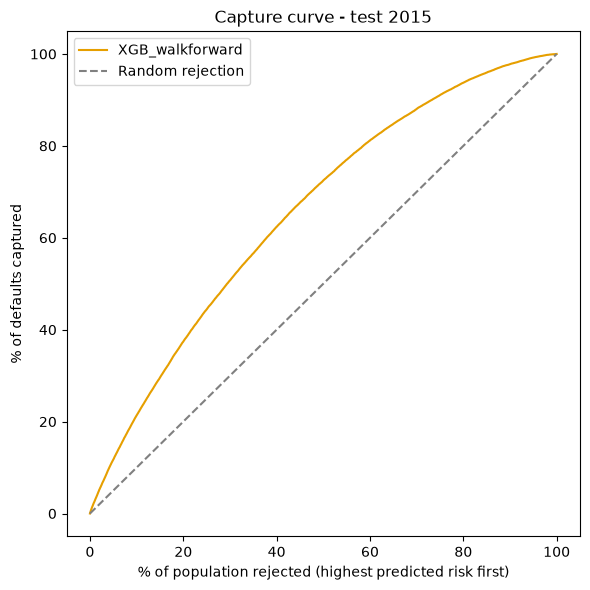

Rejecting the worst 5%: 11.7% of defaults avoided
Rejecting the worst 10%: 21.4% of defaults avoided
Rejecting the worst 20%: 37.4% of defaults avoided


In [6]:
order = np.argsort(-y_prob_xgb)
y_sorted = y_test[order]
cum_defaults = np.cumsum(y_sorted)
total_defaults = y_test.sum()
n = len(y_test)

fig, ax = plt.subplots(figsize=(6, 6))
pct_rejected = np.arange(1, n + 1) / n * 100
pct_captured = cum_defaults / total_defaults * 100
ax.plot(pct_rejected, pct_captured, color='#E69F00', label='XGB_walkforward')
ax.plot([0, 100], [0, 100], linestyle='--', color='gray', label='Random rejection')
ax.set_xlabel('% of population rejected (highest predicted risk first)')
ax.set_ylabel('% of defaults captured')
ax.set_title('Capture curve - test 2015')
ax.legend()
plt.tight_layout()
plt.show()

for frac in [0.05, 0.10, 0.20]:
    cut = int(n * frac)
    print(f'Rejecting the worst {frac*100:.0f}%: {cum_defaults[cut-1] / total_defaults * 100:.1f}% of defaults avoided')


**"Rejecting the worst 10% avoids about 21% of defaults"**, roughly double what
rejecting a random 10% would catch. This is the plainest translation of the model into a
policy statement, and it matches `notebook 13` exactly.

## Two limitations that don't show up in any of the numbers above

**Simpson's paradox in `verification_status`.** Univariately, "Verified" income
associates with a *higher* default rate than "Not Verified" (17.75% vs. 11.74%).
Lending Club verified income when something in the application already looked risky, not
as a stamp of safety. Under SHAP (controlling for all 78 other features, `notebook 13`),
the picture splits: `source verified` keeps the same direction, but plain `verified`
**reverses** to a small negative association. Part of the univariate signal was
confounded by other correlated features. (Not recomputed here: a fresh SHAP run over the
full test set is estimated at ~22 minutes in `notebook 13`. The finding is quoted, not
regenerated.)

**Selection bias.** Every number in this notebook describes performance on loans Lending
Club already chose to approve and fund. The model estimates *P(default | approved)*, not
*P(default | applicant)*. It has never seen a rejected application, and cannot say
anything about how it would perform as a first-pass underwriting filter rather than a
second-opinion layer over an already-approved book.

## Takeaway

Expected profit, not AUC, is the number that should lead any summary of this project:
+$9.03M over approving everyone, statistically distinguishable from zero and from the
logistic-regression baseline. That headline sits alongside three honest qualifications:
weaker discrimination for exactly the borrowers a lender most needs to get right, no
transferability to a different loan term, and a population that was never observed
rejecting anyone. All three are reported here because a profit number without them is not
a complete answer.

**Next:** `7.0-pipeline.ipynb`: how the frozen model is packaged for reuse, and what "not
deployed" means in practice.